In [1]:
import json
import pandas as pd
import numpy as np

from pprint import pprint

In [2]:
with open("institutional_data (1).json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Successfully loaded {len(data)} decision records.")

Successfully loaded 33 decision records.


In [3]:
print("Type of dataset:", type(data))

print("\nKeys in each decision record:\n")

for key in data[0].keys():
    print("-", key)

Type of dataset: <class 'list'>

Keys in each decision record:

- id
- title
- strategies
- constraints
- decisions
- outcomes


In [4]:
print("="*80)
print("Sample Decision Record")
print("="*80)

pprint(data[0], sort_dicts=False)

Sample Decision Record
{'id': 'decision_001',
 'title': 'Initiate Five-Year Program Review for BBA',
 'strategies': ['Form a review committee comprising the Department Head, two '
                'senior faculty, one industry representative, and the QA '
                'Office Liaison. Conduct gap analysis against UGC Program '
                'Approval Guidelines and current market needs over an '
                'eight-week period.'],
 'constraints': ['Changes require Academic Council approval at least one '
                 'semester before implementation.',
                 'All revisions must be reflected in the updated course '
                 'catalog submitted to the affiliating university.'],
 'decisions': ['Authorize the immediate execution of a comprehensive '
               'curriculum review for the BBA program to align learning '
               'modules with regional commercial practices and national '
               'university guidelines.'],
 'outcomes': ['Program rev

In [5]:
df = pd.DataFrame(data)

df.head()

,id,title,strategies,constraints,decisions,outcomes
0,decision_001,Initiate Five-Year Program Review for BBA,[Form a review committee comprising the Depart...,[Changes require Academic Council approval at ...,[Authorize the immediate execution of a compre...,[Program review completed and approved; update...
1,decision_002,Approve New MBA Specialization in Digital Finance,[Draft new specialization proposal including l...,[New program proposals must be reviewed and ap...,[Draft new specialization proposal including l...,[MBA Digital Finance specialization approved b...
2,decision_003,Adjudicate Academic Misconduct in Final Year P...,[Convene the Departmental Discipline Committee...,[Plagiarism detection tool must be used for al...,[Convening the Departmental Discipline Committ...,[Both students found in violation; grade of ze...
3,decision_004,Suspend Student for Repeat Examination Cheating,[Escalate the matter to the full Academic Coun...,[Repeat academic integrity violations must be ...,[Escalate the matter to the full Academic Coun...,[Academic Council upholds suspension for one s...
4,decision_005,Approve MOU with Commercial Bank for Internshi...,"[Draft MOU covering placement scope, student o...",[All MOUs must be reviewed by the legal/compli...,"[Draft MOU covering placement scope, student o...",[MOU signed by College Principal. Departmental...


In [6]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)

print("Number of decisions :", len(df))
print("Columns             :", list(df.columns))

DATASET SUMMARY
Number of decisions : 33
Columns             : ['id', 'title', 'strategies', 'constraints', 'decisions', 'outcomes']


In [7]:
missing = df.isnull().sum()

print(missing)

id             0
title          0
strategies     0
constraints    0
decisions      0
outcomes       0
dtype: int64


In [8]:
df["num_strategies"] = df["strategies"].apply(len)
df["num_constraints"] = df["constraints"].apply(len)
df["num_decisions"] = df["decisions"].apply(len)
df["num_outcomes"] = df["outcomes"].apply(len)

df[
    [
        "num_strategies",
        "num_constraints",
        "num_decisions",
        "num_outcomes"
    ]
].describe()

,num_strategies,num_constraints,num_decisions,num_outcomes
count,33.0,33.0,33.0,33.0
mean,1.0,2.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,1.0,2.0,1.0,1.0
25%,1.0,2.0,1.0,1.0
50%,1.0,2.0,1.0,1.0
75%,1.0,2.0,1.0,1.0
max,1.0,2.0,1.0,1.0


In [9]:
df["strategy_length"] = df["strategies"].apply(
    lambda x: sum(len(i) for i in x)
)

df["constraint_length"] = df["constraints"].apply(
    lambda x: sum(len(i) for i in x)
)

df["decision_length"] = df["decisions"].apply(
    lambda x: sum(len(i) for i in x)
)

df["outcome_length"] = df["outcomes"].apply(
    lambda x: sum(len(i) for i in x)
)

In [10]:
summary = pd.DataFrame({
    "Average Characters":[
        df["strategy_length"].mean(),
        df["constraint_length"].mean(),
        df["decision_length"].mean(),
        df["outcome_length"].mean()
    ]
},
index=[
    "Strategies",
    "Constraints",
    "Decisions",
    "Outcomes"
])

summary

,Average Characters
Strategies,242.424242
Constraints,197.515152
Decisions,152.212121
Outcomes,107.666667


In [11]:
df["total_length"] = (
      df["strategy_length"]
    + df["constraint_length"]
    + df["decision_length"]
    + df["outcome_length"]
)

largest = df.sort_values(
    "total_length",
    ascending=False
)

largest[
    [
        "id",
        "title",
        "total_length"
    ]
].head()

,id,title,total_length
28,decision_029,Terminate Defective Non-Compliant ERP Software...,765
1,decision_002,Approve New MBA Specialization in Digital Finance,755
32,decision_033,Resolve Formal Academic Appeal on Final Grade ...,743
29,decision_030,Authorize Contingency Buffer Funds for Unplann...,738
6,decision_007,Resolve Student Internship Dispute with Host O...,734


In [12]:
print("="*70)
print("COLLEGE DECISION DATASET SUMMARY")
print("="*70)

print(f"Total Decision Records : {len(df)}")

print(f"Average Strategy Length : {df.strategy_length.mean():.1f}")

print(f"Average Constraint Length : {df.constraint_length.mean():.1f}")

print(f"Average Decision Length : {df.decision_length.mean():.1f}")

print(f"Average Outcome Length : {df.outcome_length.mean():.1f}")

print(f"Largest Record : {largest.iloc[0]['id']}")

print(f"Largest Record Length : {largest.iloc[0]['total_length']} characters")

COLLEGE DECISION DATASET SUMMARY
Total Decision Records : 33
Average Strategy Length : 242.4
Average Constraint Length : 197.5
Average Decision Length : 152.2
Average Outcome Length : 107.7
Largest Record : decision_029
Largest Record Length : 765 characters


In [14]:
def whole_decision_chunking(data):
    """
    Each decision record becomes one chunk.
    """

    chunks = []

    for record in data:

        text = f"""
Decision ID:
{record['id']}

Title:
{record['title']}

Strategies:
{" ".join(record['strategies'])}

Constraints:
{" ".join(record['constraints'])}

Decision:
{" ".join(record['decisions'])}

Outcome:
{" ".join(record['outcomes'])}
"""

        chunks.append({

            "id": record["id"],

            "text": text.strip(),

            "metadata": {

                "decision_id": record["id"],
                "title": record["title"],
                "chunk_type": "whole_decision"

            }

        })

    return chunks

In [15]:
whole_chunks = whole_decision_chunking(data)

print(f"Total Chunks Created : {len(whole_chunks)}")

Total Chunks Created : 33


In [16]:
for i, chunk in enumerate(whole_chunks[:3], start=1):

    print("="*90)
    print(f"Chunk {i}")
    print("="*90)

    print("Metadata")
    print(chunk["metadata"])

    print()

    print(chunk["text"])

    print()

Chunk 1
Metadata
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'chunk_type': 'whole_decision'}

Decision ID:
decision_001

Title:
Initiate Five-Year Program Review for BBA

Strategies:
Form a review committee comprising the Department Head, two senior faculty, one industry representative, and the QA Office Liaison. Conduct gap analysis against UGC Program Approval Guidelines and current market needs over an eight-week period.

Constraints:
Changes require Academic Council approval at least one semester before implementation. All revisions must be reflected in the updated course catalog submitted to the affiliating university.

Decision:
Authorize the immediate execution of a comprehensive curriculum review for the BBA program to align learning modules with regional commercial practices and national university guidelines.

Outcome:
Program review completed and approved; updated BBA curriculum submitted to Academic Council.

Chunk 2
Metadata
{'deci

In [17]:
chunk_lengths = [len(chunk["text"]) for chunk in whole_chunks]

summary = pd.DataFrame({

    "Metric":[
        "Total Chunks",
        "Average Length",
        "Shortest Chunk",
        "Longest Chunk"
    ],

    "Value":[
        len(whole_chunks),
        round(np.mean(chunk_lengths),2),
        min(chunk_lengths),
        max(chunk_lengths)
    ]

})

summary

,Metric,Value
0,Total Chunks,33.00
1,Average Length,837.33
2,Shortest Chunk,767.00
3,Longest Chunk,907.00


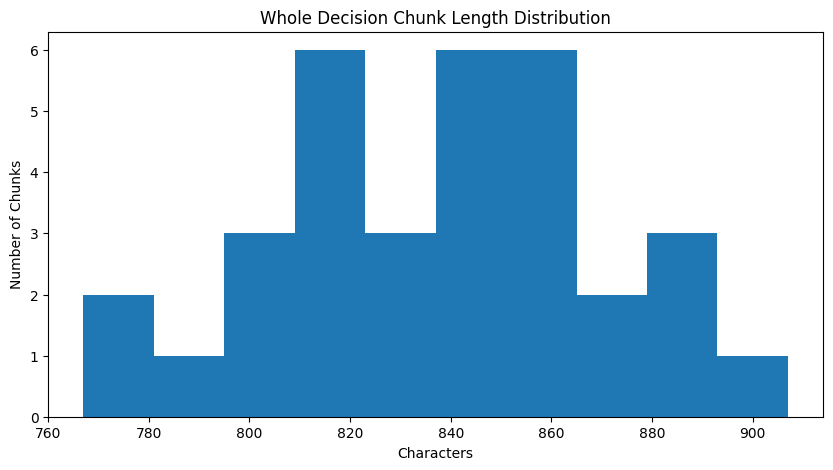

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(chunk_lengths, bins=10)

plt.title("Whole Decision Chunk Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Number of Chunks")

plt.show()

In [19]:
whole_df = pd.DataFrame({

    "Decision ID":[c["metadata"]["decision_id"] for c in whole_chunks],

    "Chunk Type":[c["metadata"]["chunk_type"] for c in whole_chunks],

    "Length":[len(c["text"]) for c in whole_chunks],

    "Preview":[c["text"][:120] + "..." for c in whole_chunks]

})

whole_df

,Decision ID,Chunk Type,Length,Preview
0,decision_001,whole_decision,839,Decision ID:\ndecision_001\n\nTitle:\nInitiate...
1,decision_002,whole_decision,891,Decision ID:\ndecision_002\n\nTitle:\nApprove ...
2,decision_003,whole_decision,833,Decision ID:\ndecision_003\n\nTitle:\nAdjudica...
3,decision_004,whole_decision,811,Decision ID:\ndecision_004\n\nTitle:\nSuspend ...
4,decision_005,whole_decision,767,Decision ID:\ndecision_005\n\nTitle:\nApprove ...
5,decision_006,whole_decision,784,Decision ID:\ndecision_006\n\nTitle:\nRenew Ex...
6,decision_007,whole_decision,878,Decision ID:\ndecision_007\n\nTitle:\nResolve ...
7,decision_008,whole_decision,799,Decision ID:\ndecision_008\n\nTitle:\nSuspend ...
8,decision_009,whole_decision,819,Decision ID:\ndecision_009\n\nTitle:\nRespond ...
9,decision_010,whole_decision,806,Decision ID:\ndecision_010\n\nTitle:\nClassify...


In [20]:
def field_chunking(data):
    """
    Split every decision into field-level chunks.
    """

    chunks = []

    for record in data:

        decision_id = record["id"]
        title = record["title"]

        # -------------------
        # Strategy Chunks
        # -------------------

        for i, strategy in enumerate(record["strategies"], start=1):

            chunks.append({

                "id": f"{decision_id}_strategy_{i}",

                "text": strategy,

                "metadata":{

                    "decision_id":decision_id,
                    "title":title,
                    "field":"strategy"

                }

            })

        # -------------------
        # Constraint Chunks
        # -------------------

        for i, constraint in enumerate(record["constraints"], start=1):

            chunks.append({

                "id":f"{decision_id}_constraint_{i}",

                "text":constraint,

                "metadata":{

                    "decision_id":decision_id,
                    "title":title,
                    "field":"constraint"

                }

            })

        # -------------------
        # Decision Chunks
        # -------------------

        for i, decision in enumerate(record["decisions"], start=1):

            chunks.append({

                "id":f"{decision_id}_decision_{i}",

                "text":decision,

                "metadata":{

                    "decision_id":decision_id,
                    "title":title,
                    "field":"decision"

                }

            })

        # -------------------
        # Outcome Chunks
        # -------------------

        for i, outcome in enumerate(record["outcomes"], start=1):

            chunks.append({

                "id":f"{decision_id}_outcome_{i}",

                "text":outcome,

                "metadata":{

                    "decision_id":decision_id,
                    "title":title,
                    "field":"outcome"

                }

            })

    return chunks

In [21]:
field_chunks = field_chunking(data)

print(f"Total Chunks Created : {len(field_chunks)}")

Total Chunks Created : 165


In [22]:
for i, chunk in enumerate(field_chunks[:10], start=1):

    print("="*90)

    print(f"Chunk {i}")

    print("="*90)

    print("Metadata")

    print(chunk["metadata"])

    print()

    print(chunk["text"])

    print()

Chunk 1
Metadata
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'field': 'strategy'}

Form a review committee comprising the Department Head, two senior faculty, one industry representative, and the QA Office Liaison. Conduct gap analysis against UGC Program Approval Guidelines and current market needs over an eight-week period.

Chunk 2
Metadata
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'field': 'constraint'}

Changes require Academic Council approval at least one semester before implementation.

Chunk 3
Metadata
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'field': 'constraint'}

All revisions must be reflected in the updated course catalog submitted to the affiliating university.

Chunk 4
Metadata
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'field': 'decision'}

Authorize the immediate execution of a comprehensive curri

In [23]:
field_df = pd.DataFrame({

    "Chunk ID":[c["id"] for c in field_chunks],

    "Decision ID":[c["metadata"]["decision_id"] for c in field_chunks],

    "Field":[c["metadata"]["field"] for c in field_chunks],

    "Length":[len(c["text"]) for c in field_chunks],

    "Preview":[c["text"][:120]+"..." for c in field_chunks]

})

field_df.head(20)

,Chunk ID,Decision ID,Field,Length,Preview
0,decision_001_strategy_1,decision_001,strategy,244,Form a review committee comprising the Departm...
1,decision_001_constraint_1,decision_001,constraint,86,Changes require Academic Council approval at l...
2,decision_001_constraint_2,decision_001,constraint,102,All revisions must be reflected in the updated...
3,decision_001_decision_1,decision_001,decision,187,Authorize the immediate execution of a compreh...
4,decision_001_outcome_1,decision_001,outcome,92,Program review completed and approved; updated...
5,decision_002_strategy_1,decision_002,strategy,247,Draft new specialization proposal including le...
6,decision_002_constraint_1,decision_002,constraint,116,New program proposals must be reviewed and app...
7,decision_002_constraint_2,decision_002,constraint,100,Revised program catalog must be submitted to t...
8,decision_002_decision_1,decision_002,decision,184,Draft new specialization proposal including le...
9,decision_002_outcome_1,decision_002,outcome,108,MBA Digital Finance specialization approved by...


In [24]:
field_lengths = [len(c["text"]) for c in field_chunks]

summary = pd.DataFrame({

    "Metric":[

        "Total Chunks",

        "Average Length",

        "Shortest Chunk",

        "Longest Chunk"

    ],

    "Value":[

        len(field_chunks),

        round(np.mean(field_lengths),2),

        min(field_lengths),

        max(field_lengths)

    ]

})

summary

,Metric,Value
0,Total Chunks,165.00
1,Average Length,139.96
2,Shortest Chunk,52.00
3,Longest Chunk,278.00


In [25]:
field_df["Field"].value_counts()

Field
constraint    66
strategy      33
decision      33
outcome       33
Name: count, dtype: int64

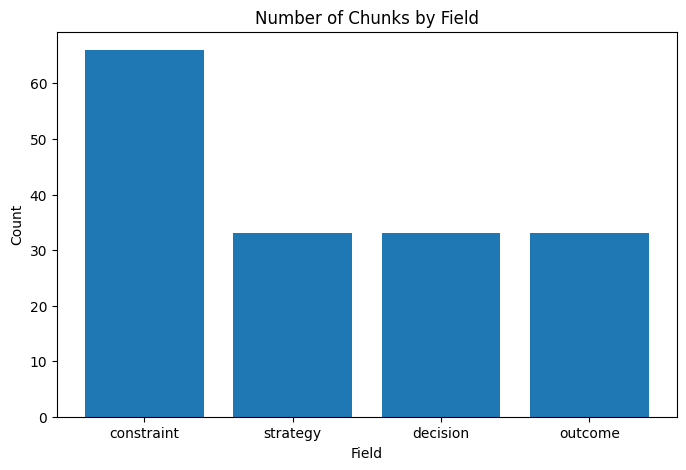

In [26]:
import matplotlib.pyplot as plt

field_counts = field_df["Field"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(field_counts.index, field_counts.values)

plt.title("Number of Chunks by Field")

plt.xlabel("Field")

plt.ylabel("Count")

plt.show()

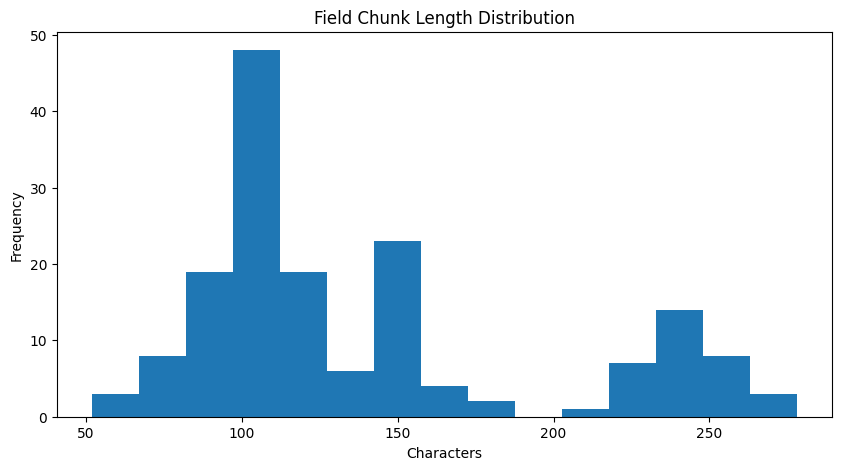

In [27]:
plt.figure(figsize=(10,5))

plt.hist(field_lengths, bins=15)

plt.title("Field Chunk Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [28]:
decision = "decision_001"

for chunk in field_chunks:

    if chunk["metadata"]["decision_id"] == decision:

        print("=" * 80)
        print(chunk["metadata"]["field"].upper())
        print("=" * 80)
        print(chunk["text"])
        print()

STRATEGY
Form a review committee comprising the Department Head, two senior faculty, one industry representative, and the QA Office Liaison. Conduct gap analysis against UGC Program Approval Guidelines and current market needs over an eight-week period.

CONSTRAINT
Changes require Academic Council approval at least one semester before implementation.

CONSTRAINT
All revisions must be reflected in the updated course catalog submitted to the affiliating university.

DECISION
Authorize the immediate execution of a comprehensive curriculum review for the BBA program to align learning modules with regional commercial practices and national university guidelines.

OUTCOME
Program review completed and approved; updated BBA curriculum submitted to Academic Council.



In [29]:
decision = "decision_001"

for chunk in field_chunks:

    if chunk["metadata"]["decision_id"] == decision:

        print("=" * 80)
        print(chunk["metadata"]["field"].upper())
        print("=" * 80)
        print(chunk["text"])
        print()

STRATEGY
Form a review committee comprising the Department Head, two senior faculty, one industry representative, and the QA Office Liaison. Conduct gap analysis against UGC Program Approval Guidelines and current market needs over an eight-week period.

CONSTRAINT
Changes require Academic Council approval at least one semester before implementation.

CONSTRAINT
All revisions must be reflected in the updated course catalog submitted to the affiliating university.

DECISION
Authorize the immediate execution of a comprehensive curriculum review for the BBA program to align learning modules with regional commercial practices and national university guidelines.

OUTCOME
Program review completed and approved; updated BBA curriculum submitted to Academic Council.



In [31]:
def pairwise_chunking(data):
    """
    Group related fields into two chunks:
    1. Strategy + Constraints
    2. Decision + Outcomes
    """

    chunks = []

    for record in data:

        decision_id = record["id"]
        title = record["title"]

        # ----------------------------
        # Planning Chunk
        # ----------------------------

        planning_text = f"""
Decision ID:
{decision_id}

Title:
{title}

Strategies:
{" ".join(record["strategies"])}

Constraints:
{" ".join(record["constraints"])}
"""

        chunks.append({

            "id": f"{decision_id}_planning",

            "text": planning_text.strip(),

            "metadata":{

                "decision_id":decision_id,
                "title":title,
                "chunk_type":"planning"

            }

        })

        # ----------------------------
        # Execution Chunk
        # ----------------------------

        execution_text = f"""
Decision ID:
{decision_id}

Title:
{title}

Decision:
{" ".join(record["decisions"])}

Outcome:
{" ".join(record["outcomes"])}
"""

        chunks.append({

            "id": f"{decision_id}_execution",

            "text": execution_text.strip(),

            "metadata":{

                "decision_id":decision_id,
                "title":title,
                "chunk_type":"execution"

            }

        })

    return chunks

In [32]:
pairwise_chunks = pairwise_chunking(data)

print(f"Total Chunks Created : {len(pairwise_chunks)}")

Total Chunks Created : 66


In [33]:
for i, chunk in enumerate(pairwise_chunks[:6], start=1):

    print("="*90)

    print(f"Chunk {i}")

    print("="*90)

    print(chunk["metadata"])

    print()

    print(chunk["text"])

    print()

Chunk 1
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'chunk_type': 'planning'}

Decision ID:
decision_001

Title:
Initiate Five-Year Program Review for BBA

Strategies:
Form a review committee comprising the Department Head, two senior faculty, one industry representative, and the QA Office Liaison. Conduct gap analysis against UGC Program Approval Guidelines and current market needs over an eight-week period.

Constraints:
Changes require Academic Council approval at least one semester before implementation. All revisions must be reflected in the updated course catalog submitted to the affiliating university.

Chunk 2
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'chunk_type': 'execution'}

Decision ID:
decision_001

Title:
Initiate Five-Year Program Review for BBA

Decision:
Authorize the immediate execution of a comprehensive curriculum review for the BBA program to align learning modules with regional 

In [34]:
pairwise_df = pd.DataFrame({

    "Chunk ID":[c["id"] for c in pairwise_chunks],

    "Decision ID":[c["metadata"]["decision_id"] for c in pairwise_chunks],

    "Chunk Type":[c["metadata"]["chunk_type"] for c in pairwise_chunks],

    "Length":[len(c["text"]) for c in pairwise_chunks],

    "Preview":[c["text"][:120]+"..." for c in pairwise_chunks]

})

pairwise_df.head(10)

,Chunk ID,Decision ID,Chunk Type,Length,Preview
0,decision_001_planning,decision_001,planning,537,Decision ID:\ndecision_001\n\nTitle:\nInitiate...
1,decision_001_execution,decision_001,execution,377,Decision ID:\ndecision_001\n\nTitle:\nInitiate...
2,decision_002_planning,decision_002,planning,576,Decision ID:\ndecision_002\n\nTitle:\nApprove ...
3,decision_002_execution,decision_002,execution,398,Decision ID:\ndecision_002\n\nTitle:\nApprove ...
4,decision_003_planning,decision_003,planning,530,Decision ID:\ndecision_003\n\nTitle:\nAdjudica...
5,decision_003_execution,decision_003,execution,389,Decision ID:\ndecision_003\n\nTitle:\nAdjudica...
6,decision_004_planning,decision_004,planning,528,Decision ID:\ndecision_004\n\nTitle:\nSuspend ...
7,decision_004_execution,decision_004,execution,364,Decision ID:\ndecision_004\n\nTitle:\nSuspend ...
8,decision_005_planning,decision_005,planning,490,Decision ID:\ndecision_005\n\nTitle:\nApprove ...
9,decision_005_execution,decision_005,execution,370,Decision ID:\ndecision_005\n\nTitle:\nApprove ...


In [35]:
pairwise_lengths = [len(c["text"]) for c in pairwise_chunks]

summary = pd.DataFrame({

    "Metric":[

        "Total Chunks",

        "Average Length",

        "Shortest Chunk",

        "Longest Chunk"

    ],

    "Value":[

        len(pairwise_chunks),

        round(np.mean(pairwise_lengths),2),

        min(pairwise_lengths),

        max(pairwise_lengths)

    ]

})

summary

,Metric,Value
0,Total Chunks,66.00
1,Average Length,460.92
2,Shortest Chunk,342.00
3,Longest Chunk,627.00


In [36]:
pairwise_df["Chunk Type"].value_counts()

Chunk Type
planning     33
execution    33
Name: count, dtype: int64

In [37]:
decision = "decision_001"

for chunk in pairwise_chunks:

    if chunk["metadata"]["decision_id"] == decision:

        print("="*80)
        print(chunk["metadata"]["chunk_type"].upper())
        print("="*80)

        print(chunk["text"])

        print()

PLANNING
Decision ID:
decision_001

Title:
Initiate Five-Year Program Review for BBA

Strategies:
Form a review committee comprising the Department Head, two senior faculty, one industry representative, and the QA Office Liaison. Conduct gap analysis against UGC Program Approval Guidelines and current market needs over an eight-week period.

Constraints:
Changes require Academic Council approval at least one semester before implementation. All revisions must be reflected in the updated course catalog submitted to the affiliating university.

EXECUTION
Decision ID:
decision_001

Title:
Initiate Five-Year Program Review for BBA

Decision:
Authorize the immediate execution of a comprehensive curriculum review for the BBA program to align learning modules with regional commercial practices and national university guidelines.

Outcome:
Program review completed and approved; updated BBA curriculum submitted to Academic Council.



In [38]:
def contextual_field_chunking(data):
    """
    Every field becomes a chunk, but each chunk also includes
    the Decision ID and Title inside the text.
    """

    chunks = []

    for record in data:

        decision_id = record["id"]
        title = record["title"]

        fields = {

            "strategy": record["strategies"],
            "constraint": record["constraints"],
            "decision": record["decisions"],
            "outcome": record["outcomes"]

        }

        for field_name, values in fields.items():

            for i, value in enumerate(values, start=1):

                chunk_text = f"""
Decision ID:
{decision_id}

Title:
{title}

Field:
{field_name.capitalize()}

Content:
{value}
"""

                chunks.append({

                    "id": f"{decision_id}_{field_name}_{i}",

                    "text": chunk_text.strip(),

                    "metadata": {

                        "decision_id": decision_id,
                        "title": title,
                        "field": field_name,
                        "chunk_type": "contextual_field"

                    }

                })

    return chunks

In [39]:
contextual_chunks = contextual_field_chunking(data)

print(f"Total Chunks Created : {len(contextual_chunks)}")

Total Chunks Created : 165


In [40]:
for i, chunk in enumerate(contextual_chunks[:8], start=1):

    print("="*100)
    print(f"Chunk {i}")
    print("="*100)

    print(chunk["metadata"])

    print()

    print(chunk["text"])

    print()

Chunk 1
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'field': 'strategy', 'chunk_type': 'contextual_field'}

Decision ID:
decision_001

Title:
Initiate Five-Year Program Review for BBA

Field:
Strategy

Content:
Form a review committee comprising the Department Head, two senior faculty, one industry representative, and the QA Office Liaison. Conduct gap analysis against UGC Program Approval Guidelines and current market needs over an eight-week period.

Chunk 2
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'field': 'constraint', 'chunk_type': 'contextual_field'}

Decision ID:
decision_001

Title:
Initiate Five-Year Program Review for BBA

Field:
Constraint

Content:
Changes require Academic Council approval at least one semester before implementation.

Chunk 3
{'decision_id': 'decision_001', 'title': 'Initiate Five-Year Program Review for BBA', 'field': 'constraint', 'chunk_type': 'contextual_field'}

Deci

In [41]:
contextual_df = pd.DataFrame({

    "Chunk ID":[c["id"] for c in contextual_chunks],

    "Decision ID":[c["metadata"]["decision_id"] for c in contextual_chunks],

    "Field":[c["metadata"]["field"] for c in contextual_chunks],

    "Length":[len(c["text"]) for c in contextual_chunks],

    "Preview":[c["text"][:120]+"..." for c in contextual_chunks]

})

contextual_df.head(20)

,Chunk ID,Decision ID,Field,Length,Preview
0,decision_001_strategy_1,decision_001,strategy,347,Decision ID:\ndecision_001\n\nTitle:\nInitiate...
1,decision_001_constraint_1,decision_001,constraint,191,Decision ID:\ndecision_001\n\nTitle:\nInitiate...
2,decision_001_constraint_2,decision_001,constraint,207,Decision ID:\ndecision_001\n\nTitle:\nInitiate...
3,decision_001_decision_1,decision_001,decision,290,Decision ID:\ndecision_001\n\nTitle:\nInitiate...
4,decision_001_outcome_1,decision_001,outcome,194,Decision ID:\ndecision_001\n\nTitle:\nInitiate...
5,decision_002_strategy_1,decision_002,strategy,358,Decision ID:\ndecision_002\n\nTitle:\nApprove ...
6,decision_002_constraint_1,decision_002,constraint,229,Decision ID:\ndecision_002\n\nTitle:\nApprove ...
7,decision_002_constraint_2,decision_002,constraint,213,Decision ID:\ndecision_002\n\nTitle:\nApprove ...
8,decision_002_decision_1,decision_002,decision,295,Decision ID:\ndecision_002\n\nTitle:\nApprove ...
9,decision_002_outcome_1,decision_002,outcome,218,Decision ID:\ndecision_002\n\nTitle:\nApprove ...


In [42]:
contextual_lengths = [
    len(c["text"])
    for c in contextual_chunks
]

summary = pd.DataFrame({

    "Metric":[

        "Total Chunks",
        "Average Length",
        "Shortest Chunk",
        "Longest Chunk"

    ],

    "Value":[

        len(contextual_chunks),

        round(np.mean(contextual_lengths),2),

        min(contextual_lengths),

        max(contextual_lengths)

    ]

})

summary

,Metric,Value
0,Total Chunks,165.00
1,Average Length,253.08
2,Shortest Chunk,163.00
3,Longest Chunk,381.00


In [43]:
from langchain_core.documents import Document

from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.vectorstores import Chroma

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9412\3444060966.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


In [44]:
embedding_models = {

    "MiniLM":
        "sentence-transformers/all-MiniLM-L6-v2",

    "BGE-Small":
        "BAAI/bge-small-en-v1.5",

    "Nomic":
        "nomic-ai/nomic-embed-text-v1"

}

In [45]:
def create_documents(chunks):

    documents = []

    for chunk in chunks:

        documents.append(

            Document(

                page_content=chunk["text"],

                metadata=chunk["metadata"]

            )

        )

    return documents

In [46]:
def benchmark_embeddings(chunks, collection_name):

    documents = create_documents(chunks)

    retrievers = {}

    for model_name, model_path in embedding_models.items():

        print(f"Creating embeddings using {model_name}...")

        embedding = HuggingFaceEmbeddings(

            model_name=model_path,

            model_kwargs={"device":"cpu"},

            encode_kwargs={"normalize_embeddings":True}

        )

        vectordb = Chroma.from_documents(

            documents=documents,

            embedding=embedding,

            collection_name=f"{collection_name}_{model_name}"

        )

        retrievers[model_name] = vectordb.as_retriever(

            search_kwargs={"k":5}

        )

    return retrievers

In [47]:
whole_retrievers = benchmark_embeddings(

    whole_chunks,

    "WholeDecision"

)

Creating embeddings using MiniLM...
Creating embeddings using BGE-Small...
Creating embeddings using Nomic...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

ValueError: nomic-ai/nomic-bert-2048 You can inspect the repository content at https://hf.co/nomic-ai/nomic-embed-text-v1.
Please pass the argument `trust_remote_code=True` to allow custom code to be run.

In [ ]:
field_retrievers = benchmark_embeddings(

    field_chunks,

    "Field"

)

In [ ]:
pairwise_retrievers = benchmark_embeddings(

    pairwise_chunks,

    "Pairwise"

)

In [ ]:
contextual_retrievers = benchmark_embeddings(

    contextual_chunks,

    "Contextual"

)

In [ ]:
question = "Who approves a new MBA specialization?"

for model_name, retriever in whole_retrievers.items():

    print("="*80)
    print(model_name)
    print("="*80)

    docs = retriever.invoke(question)

    for i, doc in enumerate(docs, start=1):

        print(f"\nResult {i}")

        print(doc.metadata)

        print(doc.page_content[:300])

        print("-"*60)

In [48]:
ground_truth = [

    {
        "question":"Who approves curriculum changes?",
        "decision_id":"decision_001"
    },

    {
        "question":"Who approves a new MBA specialization?",
        "decision_id":"decision_002"
    },

    {
        "question":"How should academic misconduct in a final year project be handled?",
        "decision_id":"decision_003"
    },

    {
        "question":"What happens after repeated examination cheating?",
        "decision_id":"decision_004"
    },

    {
        "question":"How is an internship MOU approved?",
        "decision_id":"decision_005"
    },

    {
        "question":"How is an expired MOU renewed?",
        "decision_id":"decision_006"
    },

    {
        "question":"How should an internship dispute be resolved?",
        "decision_id":"decision_007"
    },

    # Continue until decision_033

]

In [49]:
import pandas as pd

ground_truth_df = pd.DataFrame(ground_truth)

ground_truth_df.head()

,question,decision_id
0,Who approves curriculum changes?,decision_001
1,Who approves a new MBA specialization?,decision_002
2,How should academic misconduct in a final year...,decision_003
3,What happens after repeated examination cheating?,decision_004
4,How is an internship MOU approved?,decision_005


In [50]:
def evaluate_retriever(retrievers, ground_truth):

    import pandas as pd

    results = []

    for embedding_name, retriever in retrievers.items():

        print(f"\nEvaluating {embedding_name}")

        for sample in ground_truth:

            question = sample["question"]
            expected = sample["decision_id"]

            docs = retriever.invoke(question)

            retrieved_ids = [

                doc.metadata.get("decision_id","Unknown")

                for doc in docs

            ]

            results.append({

                "Embedding":embedding_name,

                "Question":question,

                "Expected":expected,

                "Retrieved Top1":retrieved_ids[0],

                "Retrieved IDs":retrieved_ids,

                "Correct":expected in retrieved_ids

            })

    return pd.DataFrame(results)

In [51]:
whole_results = evaluate_retriever(

    whole_retrievers,

    ground_truth

)

whole_results.head()

NameError: name 'whole_retrievers' is not defined

In [ ]:
whole_summary = (

    whole_results

    .groupby("Embedding")["Correct"]

    .agg(["sum","count"])

)

whole_summary["Accuracy (%)"] = (

    whole_summary["sum"]

    /

    whole_summary["count"]

    *

    100

).round(2)

whole_summary

In [ ]:
field_results = evaluate_retriever(

    field_retrievers,

    ground_truth

)

In [ ]:
pairwise_results = evaluate_retriever(

    pairwise_retrievers,

    ground_truth

)

In [ ]:
contextual_results = evaluate_retriever(

    contextual_retrievers,

    ground_truth

)